In [1]:
# CELL 1: Import required libraries and load the dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

%matplotlib inline

sns.set_theme(style="whitegrid")

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

df = pd.read_csv(URL)

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset loaded successfully.
Shape: (528, 15)
Columns: ['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence', 'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales', 'Vehicle_Type', 'City']


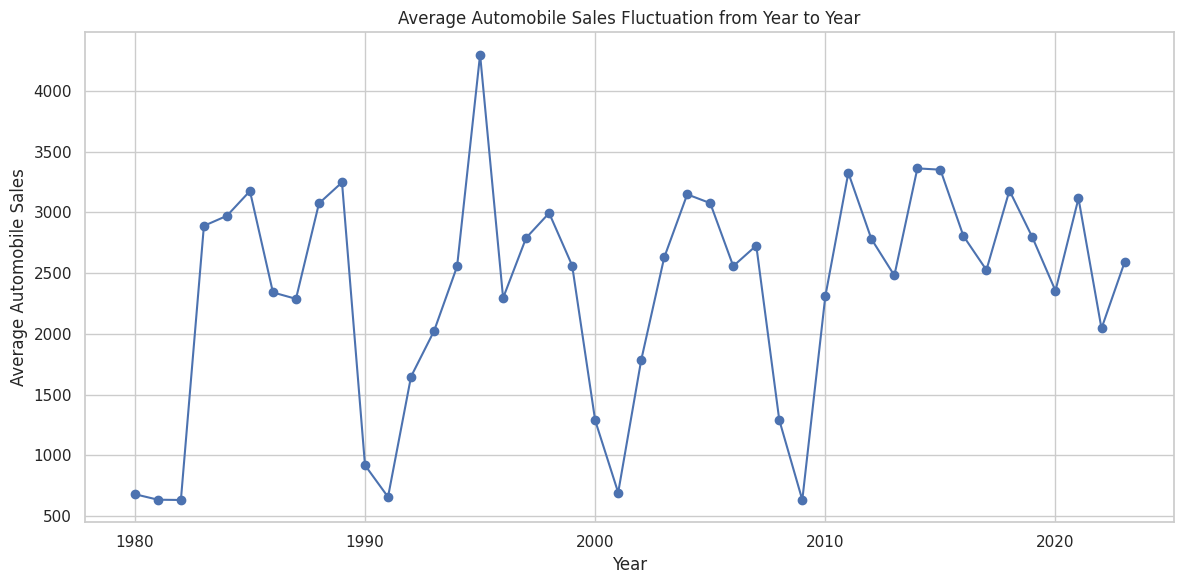

In [2]:
# CELL 2: TASK 1.1
# Line chart to show how automobile sales fluctuate from year to year

yearly_sales = df.groupby("Year")["Automobile_Sales"].mean()

yearly_sales.plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Automobile Sales")
plt.title("Average Automobile Sales Fluctuation from Year to Year")
plt.grid(True)
plt.tight_layout()

plt.savefig("Line_Plot_1.png", dpi=300, bbox_inches="tight")
plt.show()

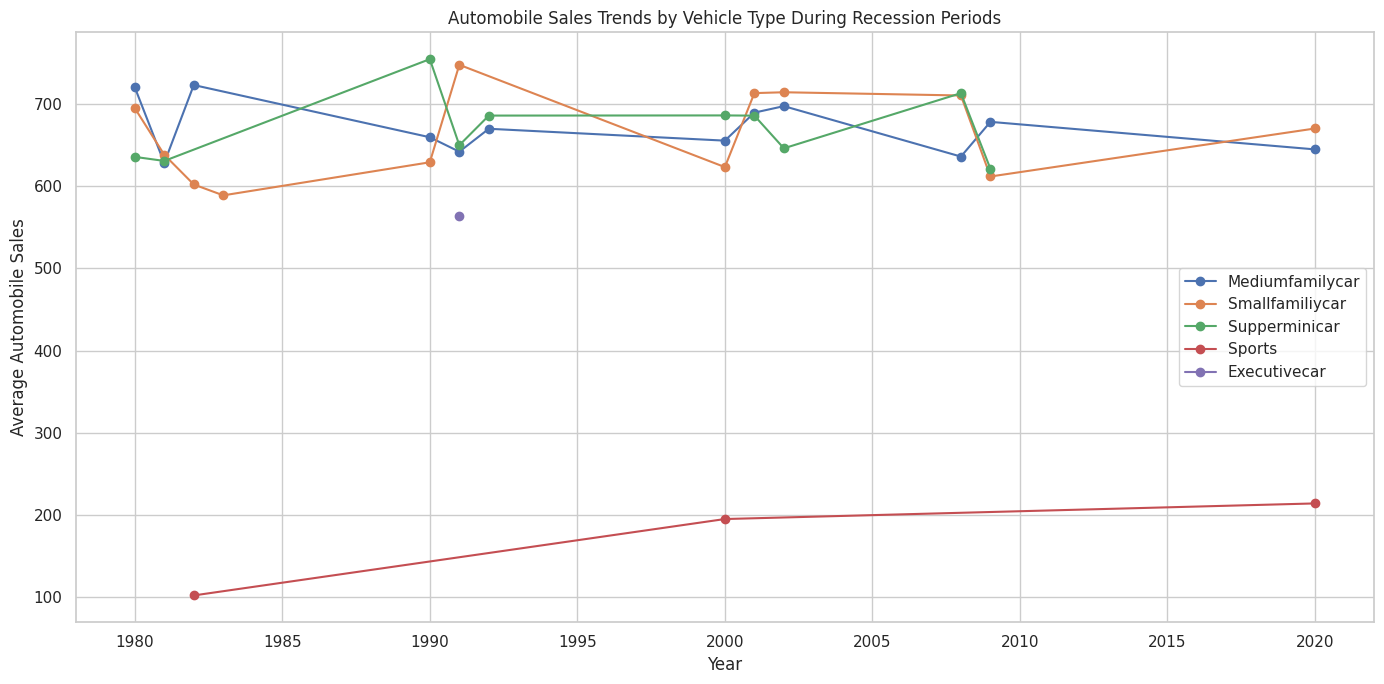

In [3]:
# CELL 3: TASK 1.2
# Plot different lines for categories of vehicle type during recession periods

recession_data = df[df["Recession"] == 1]

vehicle_sales_recession = (
    recession_data
    .groupby(["Year", "Vehicle_Type"])["Automobile_Sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))

for vehicle_type in vehicle_sales_recession["Vehicle_Type"].unique():
    vehicle_data = vehicle_sales_recession[
        vehicle_sales_recession["Vehicle_Type"] == vehicle_type
    ]

    plt.plot(
        vehicle_data["Year"],
        vehicle_data["Automobile_Sales"],
        marker="o",
        label=vehicle_type
    )

plt.xlabel("Year")
plt.ylabel("Average Automobile Sales")
plt.title("Automobile Sales Trends by Vehicle Type During Recession Periods")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("Line_Plot_2.png", dpi=300, bbox_inches="tight")
plt.show()

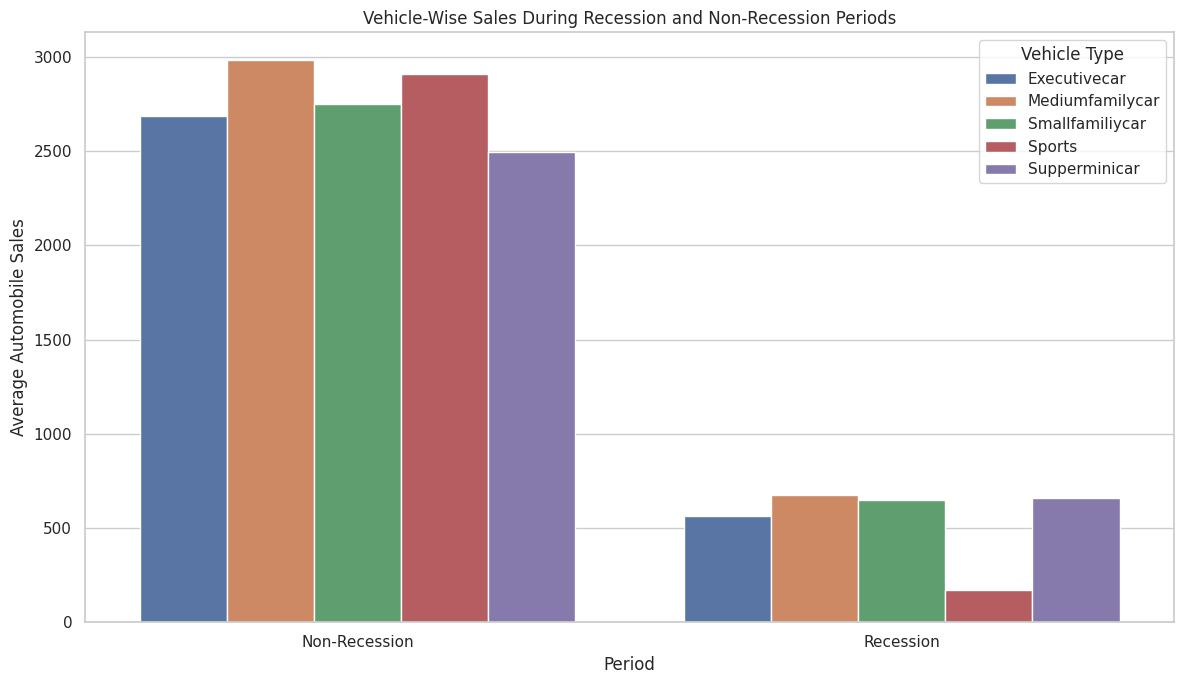

In [4]:
# CELL 4: TASK 1.3
# Seaborn visualization comparing sales per vehicle type
# during recession and non-recession periods

comparison_data = (
    df.groupby(["Recession", "Vehicle_Type"])["Automobile_Sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x="Recession",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    data=comparison_data
)

plt.xticks(
    ticks=[0, 1],
    labels=["Non-Recession", "Recession"]
)

plt.xlabel("Period")
plt.ylabel("Average Automobile Sales")
plt.title("Vehicle-Wise Sales During Recession and Non-Recession Periods")
plt.legend(title="Vehicle Type")
plt.tight_layout()

plt.savefig("Bar_Chart.png", dpi=300, bbox_inches="tight")
plt.show()

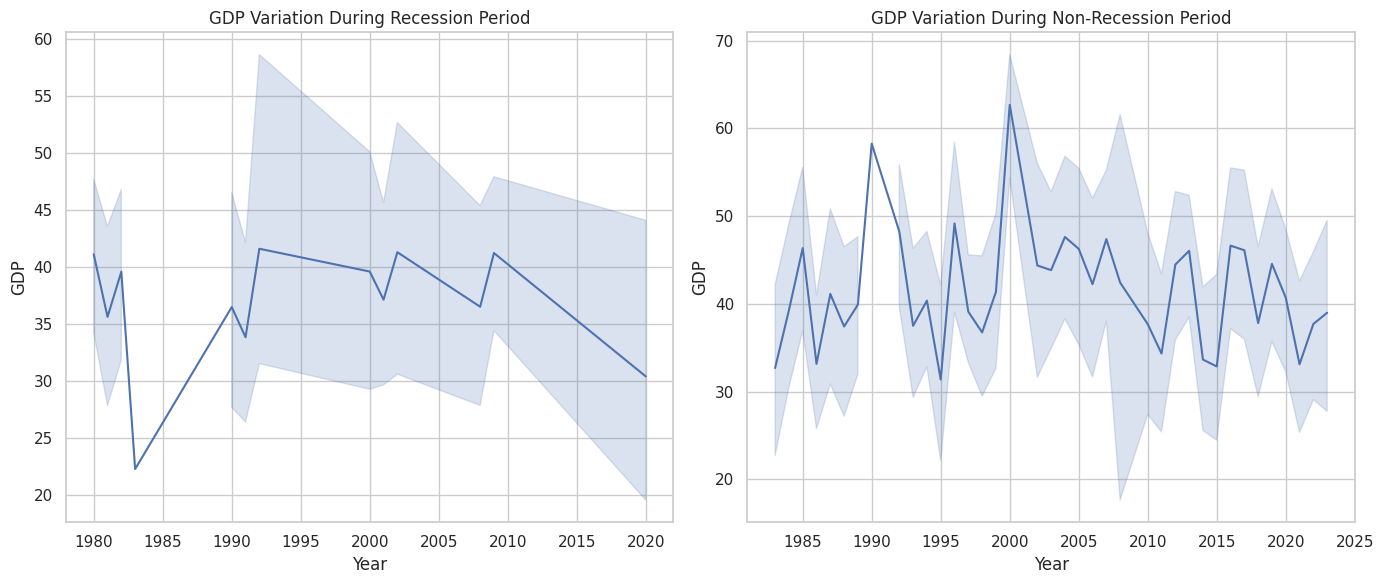

In [5]:
# CELL 5: TASK 1.4
# Subplots comparing GDP variations during recession and non-recession periods

rec_data = df[df["Recession"] == 1]
non_rec_data = df[df["Recession"] == 0]

fig = plt.figure(figsize=(14, 6))

ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)

sns.lineplot(
    x="Year",
    y="GDP",
    data=rec_data,
    ax=ax0
)

ax0.set_xlabel("Year")
ax0.set_ylabel("GDP")
ax0.set_title("GDP Variation During Recession Period")
ax0.grid(True)

sns.lineplot(
    x="Year",
    y="GDP",
    data=non_rec_data,
    ax=ax1
)

ax1.set_xlabel("Year")
ax1.set_ylabel("GDP")
ax1.set_title("GDP Variation During Non-Recession Period")
ax1.grid(True)

plt.tight_layout()

plt.savefig("Subplot.png", dpi=300, bbox_inches="tight")
plt.show()

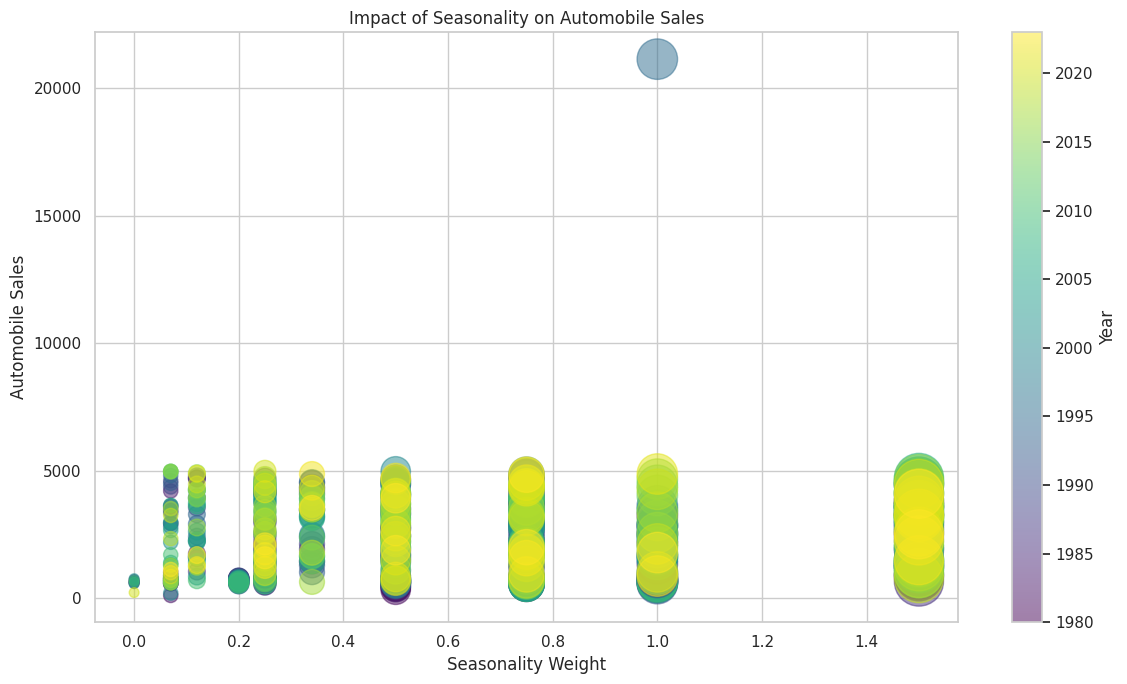

In [6]:
# CELL 6: TASK 1.5
# Bubble plot displaying the impact of seasonality on automobile sales

plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    df["Seasonality_Weight"],
    df["Automobile_Sales"],
    s=df["Seasonality_Weight"] * 800 + 50,
    alpha=0.5,
    c=df["Year"],
    cmap="viridis"
)

plt.xlabel("Seasonality Weight")
plt.ylabel("Automobile Sales")
plt.title("Impact of Seasonality on Automobile Sales")

cbar = plt.colorbar(scatter)
cbar.set_label("Year")

plt.grid(True)
plt.tight_layout()

plt.savefig("Bubble.png", dpi=300, bbox_inches="tight")
plt.show()

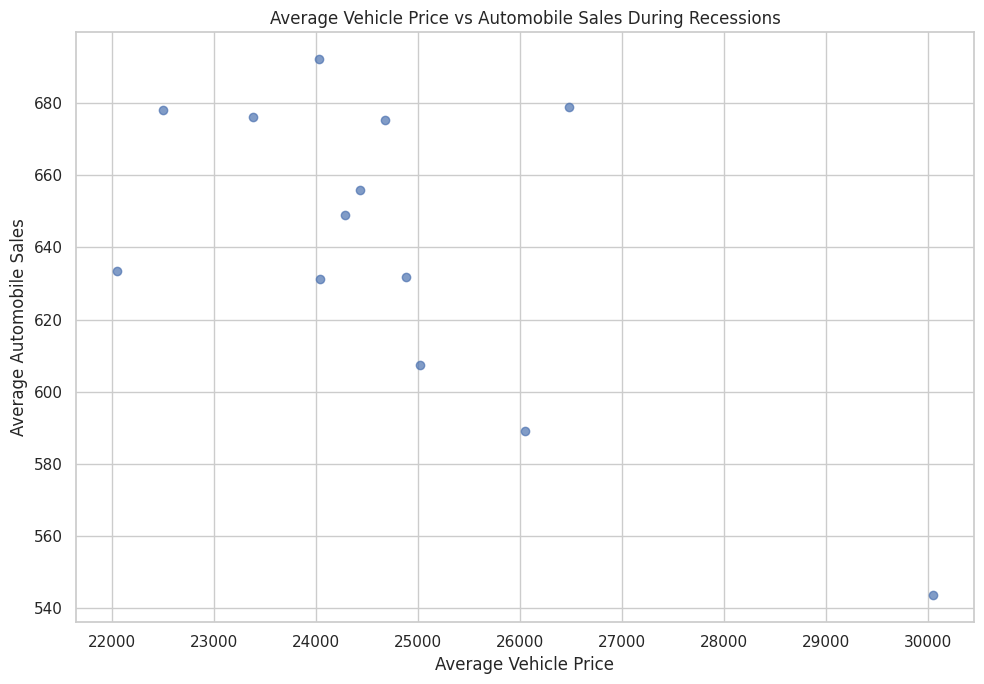

Correlation between average vehicle price and automobile sales: -0.663453507473254


In [7]:
# CELL 7: TASK 1.6
# Scatter plot showing correlation between average vehicle price
# and automobile sales during recessions

recession_data = df[df["Recession"] == 1]

price_sales = (
    recession_data
    .groupby("Year")[["Price", "Automobile_Sales"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 7))

plt.scatter(
    price_sales["Price"],
    price_sales["Automobile_Sales"],
    alpha=0.7
)

plt.xlabel("Average Vehicle Price")
plt.ylabel("Average Automobile Sales")
plt.title("Average Vehicle Price vs Automobile Sales During Recessions")
plt.grid(True)
plt.tight_layout()

plt.savefig("Scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print(
    "Correlation between average vehicle price and automobile sales:",
    price_sales["Price"].corr(price_sales["Automobile_Sales"])
)

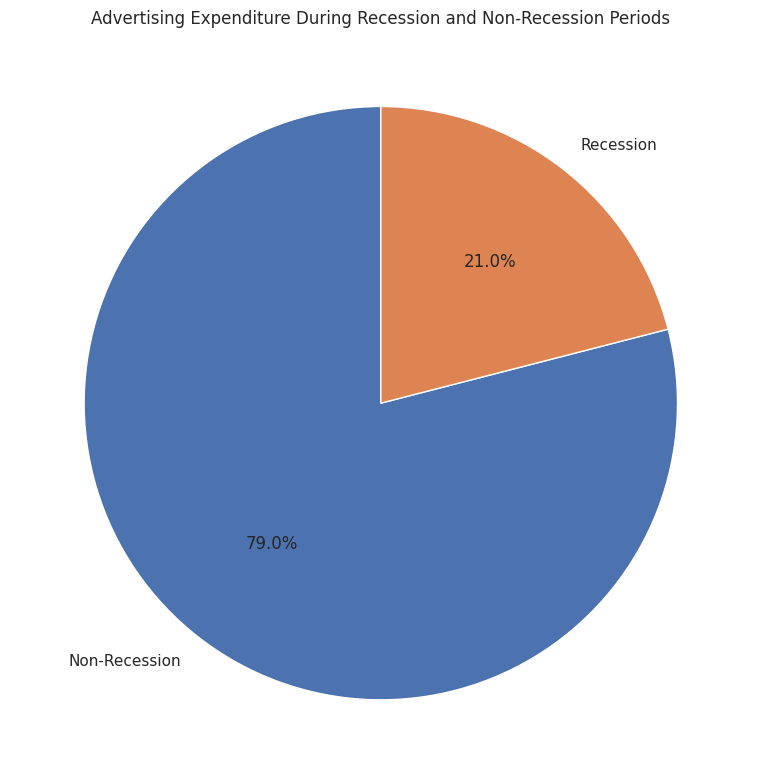

In [8]:
# CELL 8: TASK 1.7
# Pie chart showing the portion of advertising expenditure
# during recession and non-recession periods

advertising_by_period = (
    df.groupby("Recession")["Advertising_Expenditure"]
    .sum()
)

advertising_by_period.index = [
    "Non-Recession",
    "Recession"
]

plt.figure(figsize=(8, 8))

plt.pie(
    advertising_by_period.values,
    labels=advertising_by_period.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Advertising Expenditure During Recession and Non-Recession Periods")

plt.tight_layout()

plt.savefig("Pie_1.png", dpi=300, bbox_inches="tight")
plt.show()

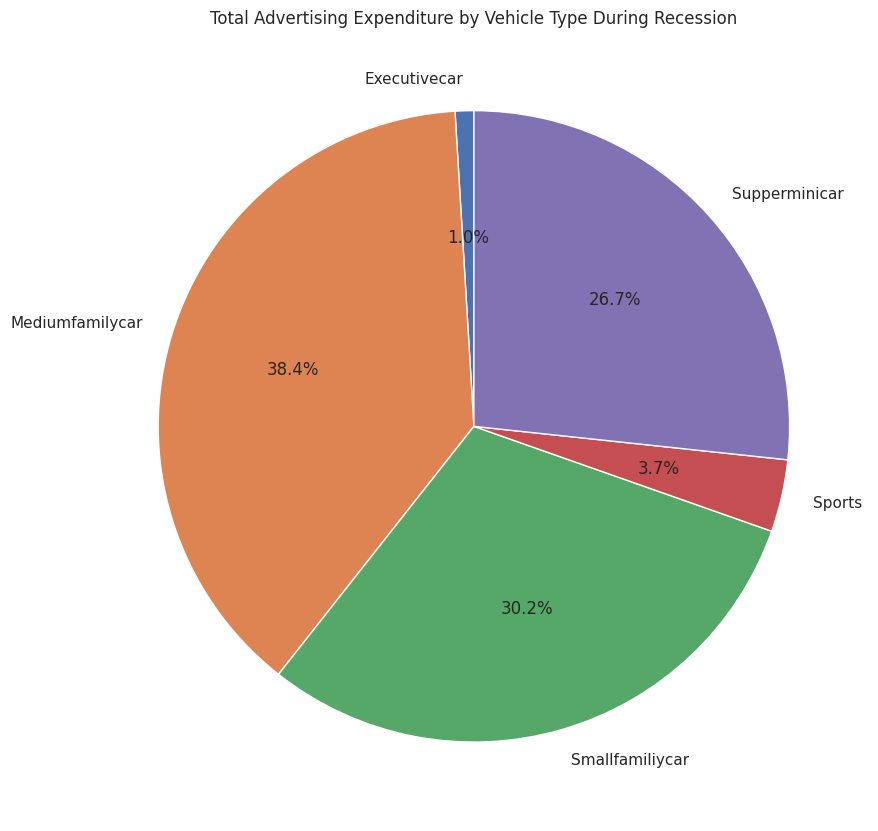

In [9]:
# CELL 9: TASK 1.8
# Pie chart showing total advertising expenditure
# for each vehicle type during recession

recession_advertising = (
    recession_data
    .groupby("Vehicle_Type")["Advertising_Expenditure"]
    .sum()
)

plt.figure(figsize=(9, 9))

plt.pie(
    recession_advertising.values,
    labels=recession_advertising.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Total Advertising Expenditure by Vehicle Type During Recession"
)

plt.tight_layout()

plt.savefig("Pie_2.png", dpi=300, bbox_inches="tight")
plt.show()

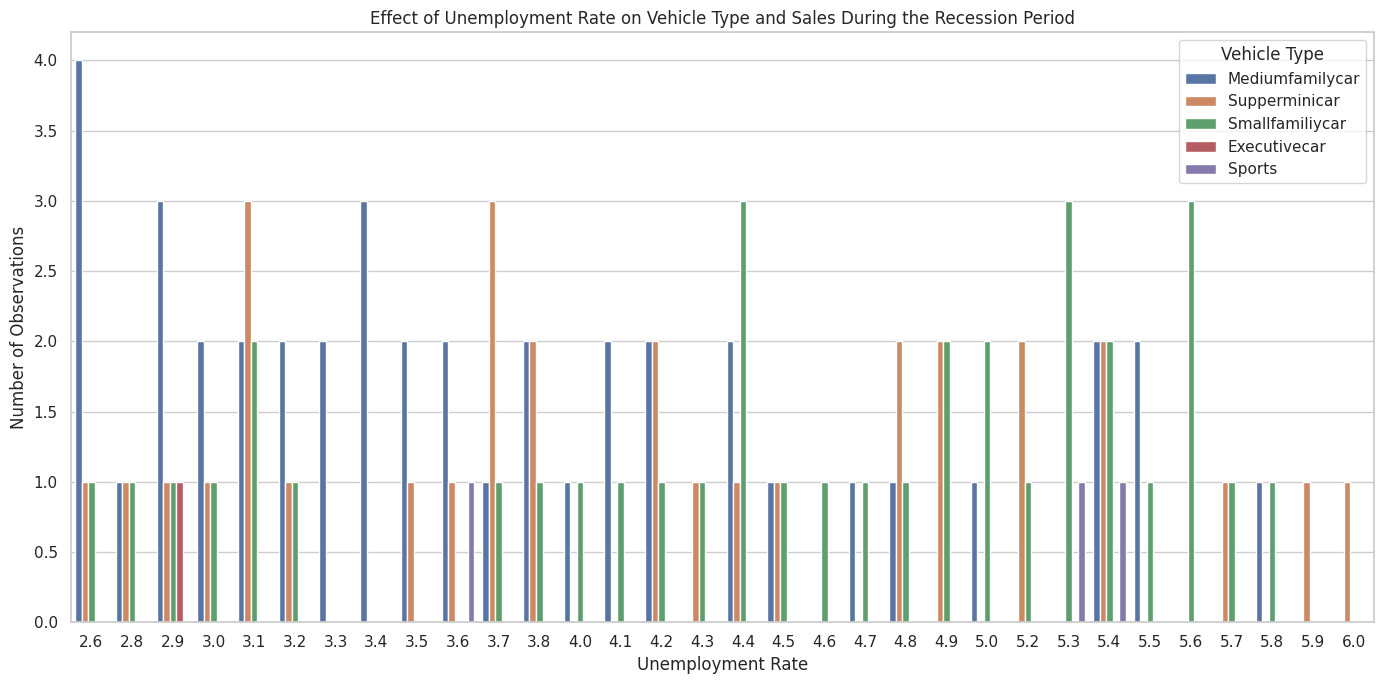

In [10]:
# CELL 10: TASK 1.9
# Countplot analyzing the effect of unemployment rate
# on vehicle type and sales during the recession period

recession_data = df[df["Recession"] == 1]

plt.figure(figsize=(14, 7))

sns.countplot(
    data=recession_data,
    x="unemployment_rate",
    hue="Vehicle_Type"
)

plt.xlabel("Unemployment Rate")
plt.ylabel("Number of Observations")
plt.title(
    "Effect of Unemployment Rate on Vehicle Type and Sales "
    "During the Recession Period"
)

plt.legend(
    title="Vehicle Type",
    loc="upper right"
)

plt.tight_layout()

plt.savefig("Count_Plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# CELL 11: Optional Folium visualization
# Interactive map showing automobile sales by city during recession periods

recession_data = df[df["Recession"] == 1]

sales_by_city = (
    recession_data
    .groupby("City")["Automobile_Sales"]
    .sum()
    .reset_index()
)

city_coordinates = {
    "New York": [40.7128, -74.0060],
    "Los Angeles": [34.0522, -118.2437],
    "Chicago": [41.8781, -87.6298],
    "Houston": [29.7604, -95.3698],
    "Phoenix": [33.4484, -112.0740],
    "Philadelphia": [39.9526, -75.1652],
    "San Antonio": [29.4241, -98.4936],
    "San Diego": [32.7157, -117.1611],
    "Dallas": [32.7767, -96.7970],
    "San Jose": [37.3382, -121.8863]
}

map1 = folium.Map(
    location=[37.0902, -95.7129],
    zoom_start=4
)

for _, row in sales_by_city.iterrows():

    city = row["City"]

    if city in city_coordinates:
        folium.CircleMarker(
            location=city_coordinates[city],
            radius=max(5, row["Automobile_Sales"] / 1000),
            popup=(
                f"City: {city}<br>"
                f"Automobile Sales: {row['Automobile_Sales']:,.0f}"
            ),
            tooltip=city,
            fill=True
        ).add_to(map1)

map1.save("Automobile_Sales_Recession_Map.html")

map1

In [12]:
# CELL 12: Final verification

print("Notebook verification")
print("-" * 40)

print("Dataset shape:", df.shape)
print("Number of years:", df["Year"].nunique())
print("Number of vehicle types:", df["Vehicle_Type"].nunique())
print("Number of recession records:", len(recession_data))

print("\nGenerated visualization files:")
print("1. Line_Plot_1.png")
print("2. Line_Plot_2.png")
print("3. Bar_Chart.png")
print("4. Subplot.png")
print("5. Bubble.png")
print("6. Scatter.png")
print("7. Pie_1.png")
print("8. Pie_2.png")
print("9. Count_Plot.png")
print("10. Automobile_Sales_Recession_Map.html")

Notebook verification
----------------------------------------
Dataset shape: (528, 15)
Number of years: 44
Number of vehicle types: 5
Number of recession records: 113

Generated visualization files:
1. Line_Plot_1.png
2. Line_Plot_2.png
3. Bar_Chart.png
4. Subplot.png
5. Bubble.png
6. Scatter.png
7. Pie_1.png
8. Pie_2.png
9. Count_Plot.png
10. Automobile_Sales_Recession_Map.html
